# Business Questions

**Dataset**: UK gift shop transactions, 2010–2011.

**Business Questions**:
1. Which products are most popular by quantity sold?
2. Which countries generate the most revenue?

**Useful for**: Shop owner and marketing team to improve sales strategy.

# 01 Load_Cleaning_Preprocessing

Goal: Load data, identify and fix data issues

### Loading

In [1079]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
e_co_raw_df = pd.read_csv('../data/e-commerce.csv', encoding='latin-1')


### Preprocessing

In [1080]:
#Changing the datatype of InvoiceDate from string to usable datetime format
df=e_co_raw_df.copy()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.month

In [1081]:
df['Revenue']=df['Quantity']*df['UnitPrice']

### Identifying Issues 

In [1082]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,20.34


Obeservation 1: 84029* variants differ in suffix only — not product variants. description.

Action 1: Prioritize other cleaning issues first 

In [1083]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Month,Revenue
count,541909.000000,541909,541909.000000,406829.000000,541909.000000,541909.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570,7.553128,17.987795
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,1.000000,-168469.600000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,5.000000,3.400000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,8.000000,9.750000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,11.000000,17.400000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,12.000000,168469.600000
std,218.081158,NaN,96.759853,1713.600303,3.509055,378.810824


Observation 1: Quantity and UnitPrice contain negative values 
               and extreme outliers.

Action 1: Filter out negative Quantity and UnitPrice 
          (likely returns/errors) during Cleaning.

Action 2: Note outliers — investigate later if they 
          affect analysis results.

In [1084]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
 8   Month        541909 non-null  int32         
 9   Revenue      541909 non-null  float64       
dtypes: datetime64[us](1), float64(3), int32(1), int64(1), str(4)
memory usage: 39.3 MB


Observation 1: CustomerID has missing values.

Action 1: Explore missing customer patterns before cleaning.

Observation 2: Description has missing values.

Action 1: Explore missing product patterns before cleaning.

Observation 3: InvoiceDate is not datetime.

Action 1: Convert before time analysis.

In [1085]:
# To view whether how long does the record spans
df['InvoiceDate'].agg(['min', 'max'])

min   2010-12-01 08:26:00
max   2011-12-09 12:50:00
Name: InvoiceDate, dtype: datetime64[us]

In [1086]:
print(e_co_raw_df.shape)  # 應該是 (541909, 8)
print(df.shape)

(541909, 8)
(541909, 10)


### Cleaning

Since the project's aim is not calculating the return rate of a product and identify reasons of return.

We will remove or the negative values 

In [1087]:
df_clean = df[(df['Quantity'] > 0) & (df['UnitPrice'] >= 0)]

In [1088]:
df_clean.shape

(531283, 10)

In [1089]:
df['UnitPrice'].dtype

dtype('float64')

In [1091]:
# Calculating and comparing the missing ratio of CustomerID and Description respectively
Missing_ratio_CustomerID=(df_clean['CustomerID'].isna().sum())/len(df_clean['CustomerID'])
Missing_ratio_Description=(df_clean['Description'].isna().sum())/len(df_clean['Description'])
print("The missing report:")
print(f"The number of missing records of CustomerID: {df_clean['CustomerID'].isna().sum()}")
print(f"The number of missing records of Description: {df_clean['Description'].isna().sum()}")
print()

print(f'The percentage of missing CustomerID: {Missing_ratio_CustomerID*100}')
print(f'The percentage of missing Description: {Missing_ratio_Description*100}')

The missing report:
The number of missing records of CustomerID: 133359
The number of missing records of Description: 592

The percentage of missing CustomerID: 25.101311353835904
The percentage of missing Description: 0.11142837244933491


Observation 1: ~25% CustomerID missing 

Action 1: Filter and inspect patterns

Action 2: Compare later only if the missing group shows a clear clue.

Observation 2: ~0.111% Description missing

Actions: Same approach as observation 1

In [1093]:
#Filtering out all the 'CustomerID' missing records in.
CustomerID_NaN=df[df['CustomerID'].isna()]
CustomerID_NaN.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month,Revenue
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom,12,0.00
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom,12,2.51
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom,12,5.02
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom,12,3.40
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom,12,3.32


self action compare missing and non miss with df.describe

Obeservation 1: The first record as both description and customerID NaN and the unitprice is 0.0.

Action 1: Identify is decrption NaN also paired with CustomerID NaN

Observation 2: The 5 records are on the same day

Action 1: Make a line chart of months especially december.


Text(0, 0.5, 'The number of Invoice')

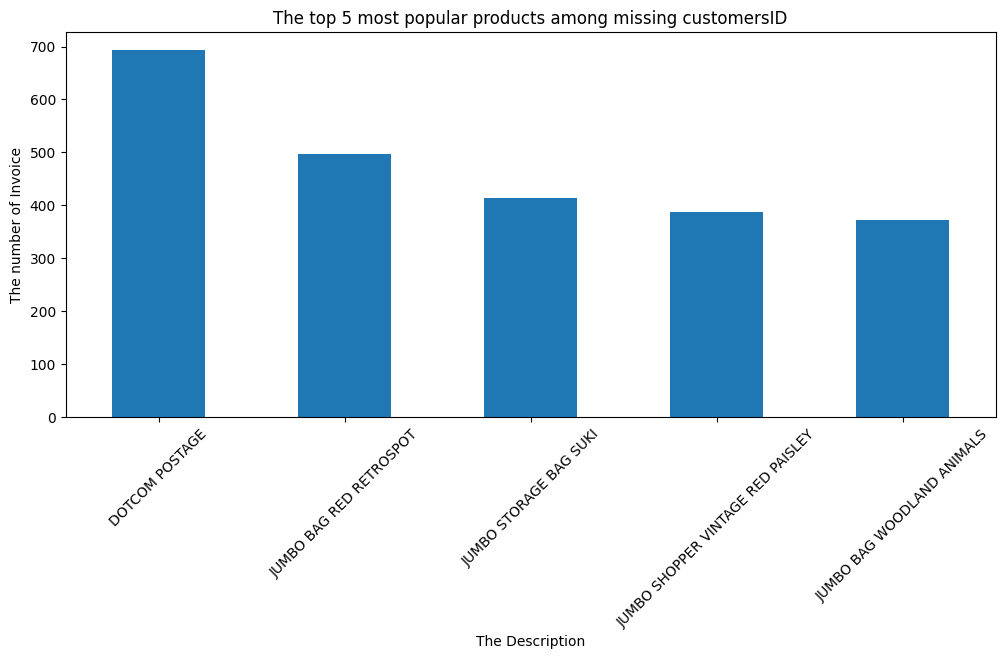

In [1094]:
plt.figure(figsize=(12, 5))
plt.tight_layout()

CustomerID_NaN['Description'].value_counts().sort_values(ascending=False).head().plot(kind='bar')
plt.title("The top 5 most popular products among missing customersID")
plt.xticks(rotation=45)
plt.xlabel("The Description")
plt.ylabel("The number of Invoice")

Observation 1: Jumbo has occcupied 4 seats

action 1: See whether Jumbo brand has occupied most the NaN records

Obeservation 2: DOTCOM POSTAGE is most popular but does not occupy high percentage in missing records.

action 1: calculate the number of invoice of DOtcom against total missing records

In [1095]:
dotcom_over_total=len(CustomerID_NaN[CustomerID_NaN['Description']=='DOTCOM POSTAGE'])/len(CustomerID_NaN)
print(f' The percentage of records that DOTCOM POSTAGE has occcupied {dotcom_over_total*100} percent')

 The percentage of records that DOTCOM POSTAGE has occcupied 0.5130293159609121 percent


Obeservation 1: DOTCOM POSTAGE is most popular but does not occupy high percentage in missing records.

action 1: calculate the number of invoice of DOtcom against total missing records


action:Whether products with the most records are evenly distributed Check the mean agains DOTCOM postage

In [1096]:
type(CustomerID_NaN['Description'].value_counts())

pandas.Series

In [1111]:
print(f'The mean, median and standard deviation of number of records in each product/ description')
print(f'The mean: {CustomerID_NaN['Description'].value_counts().mean()}')
print(f'The median: {CustomerID_NaN['Description'].value_counts().median()}')
print(f'The standard deviation {CustomerID_NaN['Description'].value_counts().std()}')


The mean, median and standard deviation of number of records in each product/ description
The mean: 37.59876195835678
The median: 21.0
The standard deviation 49.733457393203885


Observation 1: Highly right skewed as std > mean and mean > median

action 1: identify and decision to clean outliers

In [1100]:
No_Jumbo_records=len(CustomerID_NaN[CustomerID_NaN['Description'].str.contains('JUMBO')])

print(f'The percentage of number of JUMBO products {No_Jumbo_records/len(CustomerID_NaN)*100}')

The percentage of number of JUMBO products 3.9991116375481193


Obeservation: JUMBO brand does not occupies most records in the numbrer of records.

Lets look at the patterns by quantity

In [1101]:
Description_Quantity=CustomerID_NaN.groupby('Description')['Quantity'].sum()

In [1102]:
Description_Quantity=Description_Quantity.sort_values(ascending=False)

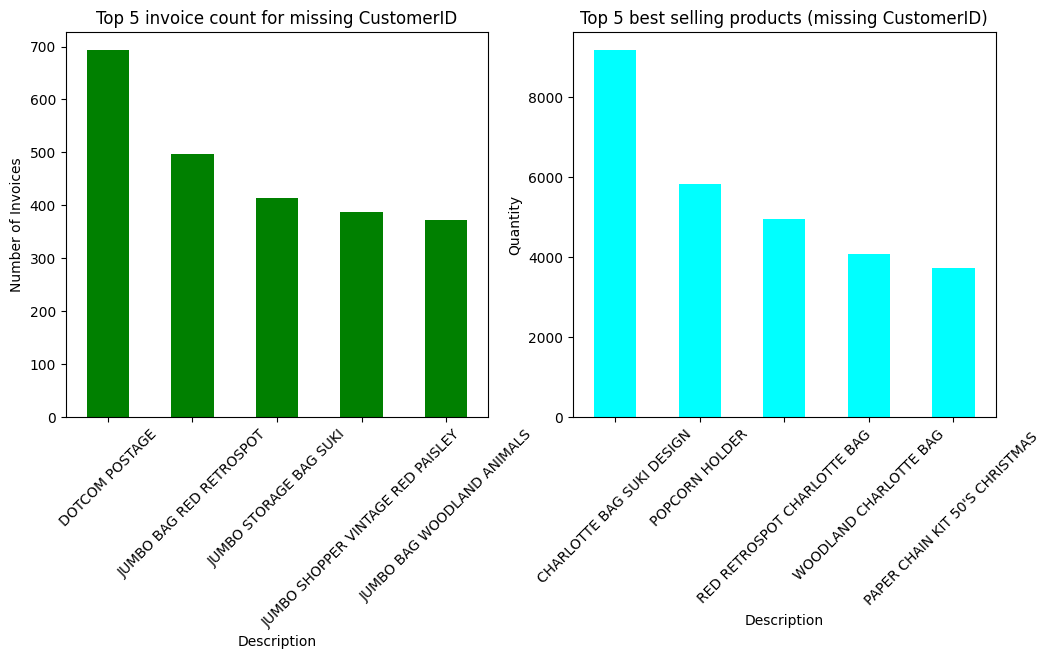

In [1103]:
fig, ax=plt.subplots(1,2, figsize=(12,5))
CustomerID_NaN['Description'].value_counts().sort_values(ascending=False).head().plot(kind='bar', ax=ax[0], color='green')
ax[0].set_title("Top 5 invoice count for missing CustomerID")
ax[0].set_xlabel("Description")
ax[0].set_ylabel("Number of Invoices")
ax[0].tick_params(axis='x', rotation=45)  # ✅ 精準控制 ax[0]

Description_Quantity.head().plot(kind='bar', ax=ax[1], color='cyan')
ax[1].set_title('Top 5 best selling products (missing CustomerID)')
ax[1].set_xlabel('Description')
ax[1].set_ylabel('Quantity')
ax[1].tick_params(axis='x', rotation=45)  # ✅ 精準控制 ax[1]
plt.show()

In [ ]:
jumbo_quantity=CustomerID_NaN[CustomerID_NaN['Description'].str.contains('JUMBO')]['Quantity'].sum()
print(f"The percentile of jumbo against the total number of customerIDs: {jumbo_quantity/CustomerID_NaN['Quantity'].sum()*100}")



The percentile of jumbo against the total number of customerIDs: 9.003494557838271


Conclusion between records and quantity: They have no relationships

We can see that jumbo brand products still occupies a mere sector of the total

In [1105]:
#Std of quantity
print(f'The mean, median and the standard deviation of the quantity of each product')
print(f'The median: {Description_Quantity.mean()}')
print(f'The mean: {Description_Quantity.median()}')
print(f'The standard deviation {Description_Quantity.std()}')
print()
print('_'*100)
print(f'The mean, median and standard deviation of number of records in each product/ description')
print(f'The mean: {CustomerID_NaN['Description'].value_counts().mean()}')
print(f'The median: {CustomerID_NaN['Description'].value_counts().median()}')
print(f'The standard deviation {CustomerID_NaN['Description'].value_counts().std()}')


The mean, median and the standard deviation of the quantity of each product
The median: 79.67670230725943
The mean: 37.0
The standard deviation 644.7302980315237

____________________________________________________________________________________________________
The mean, median and standard deviation of number of records in each product/ description
The mean: 37.59876195835678
The median: 21.0
The standard deviation 49.733457393203885


Obeservation 1: both of the quantity and records are in right skewed as mean > median

action 1: highlight outliers and identify whether clean them is necessary or not

Obeservation 2: Quantity has huge amount of std indicatting huge outliers 

action: same as observation 1



#### Description sheet

In [1106]:
#The filtering out the missing description
Description_NaN=df[df['Description'].isna()]

In [1107]:
#Investigating whether description NaN records are the subsets of CustomerID NaNs
Description_NaN.isna().sum()

InvoiceNo         0
StockCode         0
Description    1454
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID     1454
Country           0
Month             0
Revenue           0
dtype: int64

In [1108]:
free_products=df[(~df['Description'].isna()) & (df['UnitPrice']==0.0)]
free_products_name=free_products['Description'].unique().tolist()
free_products_name[0:10]

['amazon',
 '?',
 'ROUND CAKE TIN VINTAGE GREEN',
 'check',
 'damages',
 'CREAM SWEETHEART LETTER RACK',
 'ZINC WILLIE WINKIE  CANDLE STICK',
 'BOX OF 24 COCKTAIL PARASOLS',
 'DOORMAT ENGLISH ROSE ',
 'DOORMAT 3 SMILEY CATS']

Obeservation 1: Descriptions NaNs are the subset of CustomerID as all descriptions have CustomerID as NaN

Action 2: Compare line chart of missing descriptions and customerID to find their relations

In [1109]:
print(f'The number of description NaN records is zero :{len(Description_NaN[Description_NaN['UnitPrice']==0.0])}')

The number of description NaN records is zero :1454


Text(619.9949494949494, 0.5, 'Number of Records')

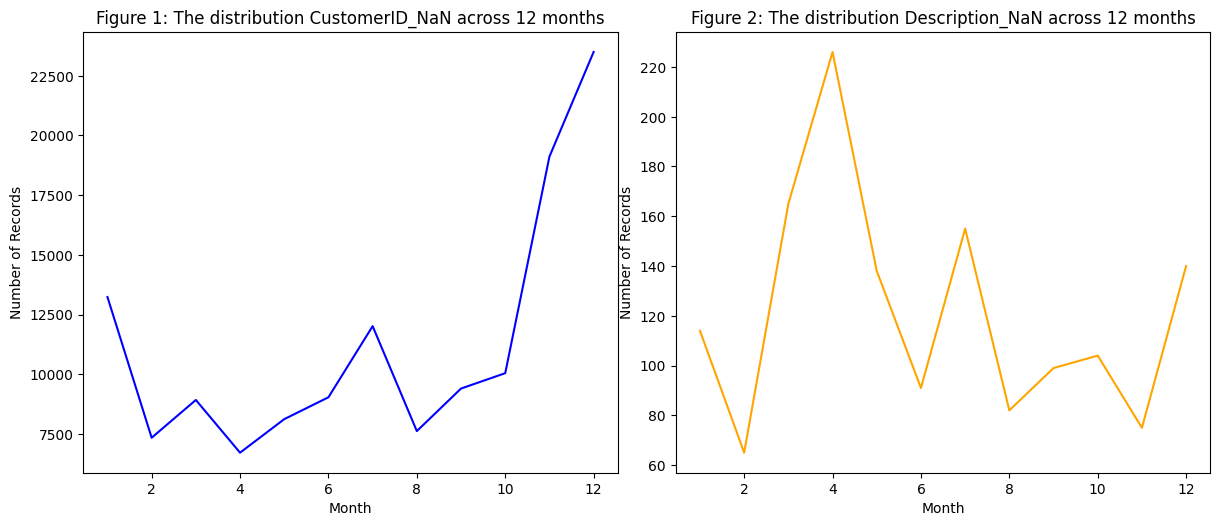

In [1110]:
fig,ax=plt.subplots(1,2,figsize=(12, 5))
plt.tight_layout()
CustomerID_NaN['Month'].value_counts().sort_index().plot(kind='line', color='blue', ax=ax[0])
ax[0].set_title("Figure 1: The distribution CustomerID_NaN across 12 months")
ax[0].set_xlabel("Month")
ax[0].set_ylabel("Number of Records")

Description_NaN['Month'].value_counts().sort_index().plot(kind='line', color='orange', ax=ax[1])
ax[1].set_title("Figure 2: The distribution Description_NaN across 12 months")
ax[1].set_xlabel("Month")
ax[1].set_ylabel("Number of Records")

Obeservation 1: Strong trend of increasing missing records are spotted from october to december (Fig 1).


Obeservation 2: (Fig 2) There are two strong bumps in april and july

Obeservation 3: (Figure 1 & 2) have no relationships.

action: Scatter plot to prove whether the claim of observation 3 is correct or not


**Self notes: However the dataset start from 2010 december it would added to 2011 december which masks the number of customers in december (Advanced data question)**

# 02 Transformation

# 03 Analyse

# 04 Insight and Conclusion